<a href="https://colab.research.google.com/github/isha3456/Isha-/blob/main/24_06_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


===== DATASET ====
   CGPA  Attendance  CodingScore  CommunicationScore  Projects  \
0   8.5          92           90                  85         5   
1   7.2          85           75                  70         3   
2   9.1          96           95                  88         6   
3   6.8          75           60                  65         2   
4   8.0          88           82                  80         4   
5   9.3          98           98                  90         7   
6   7.5          80           70                  72         3   
7   8.8          94           91                  86         5   
8   6.9          72           58                  60         2   
9   8.2          89           85                  82         4   

   InternshipScore  Package  PlacementStatus            CareerDomain  
0               88     12.0                1                   AI/ML  
1               70      6.0                1         Web Development  
2               92     15.0             

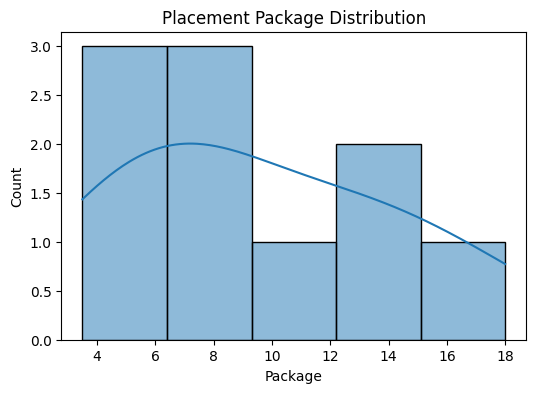

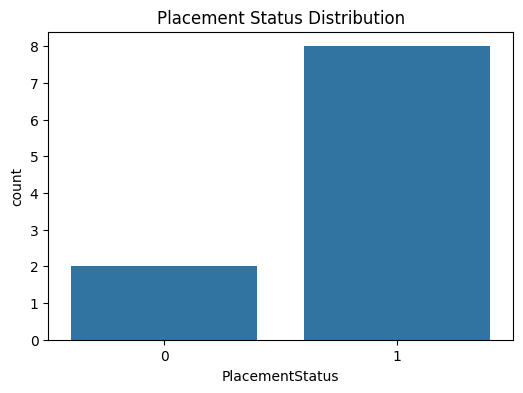

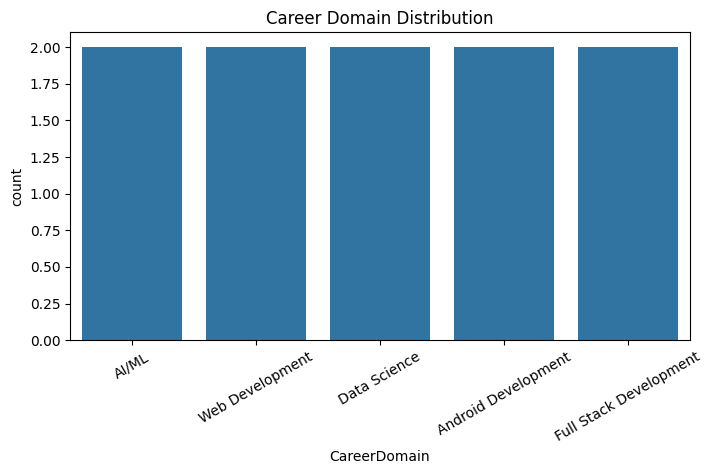

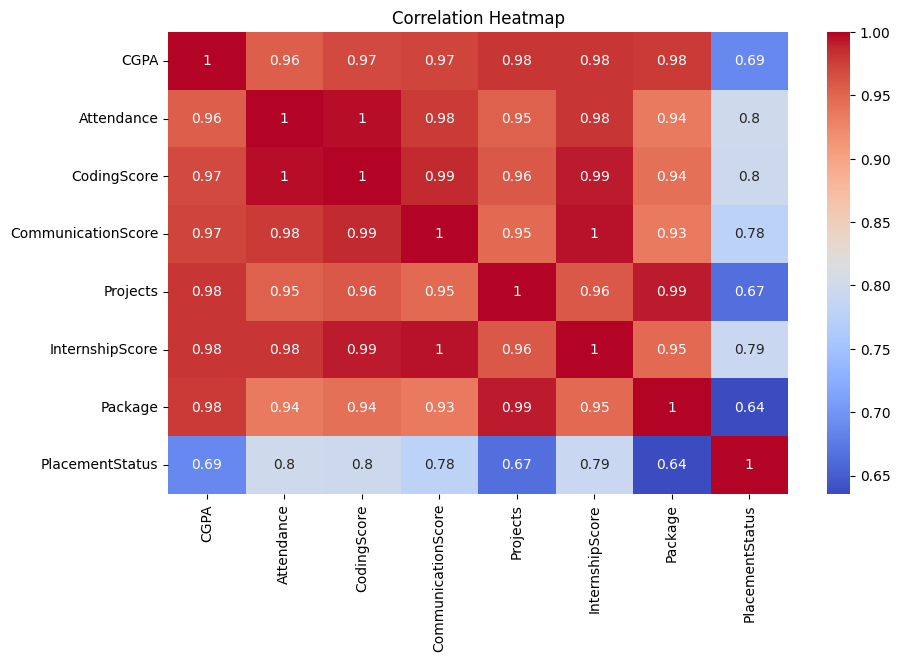


===== LINEAR REGRESSION ====
R2 Score : -2394.9271
MAE      : 56.1026

===== LOGISTIC REGRESSION ====
Accuracy : 1.0

Confusion Matrix
[[1 0]
 [0 1]]

===== KNN CLASSIFICATION ====

Accuracy for Different K Values
K = 1 --> Accuracy = 1.00
K = 2 --> Accuracy = 0.50
K = 3 --> Accuracy = 0.50
K = 4 --> Accuracy = 0.00
K = 5 --> Accuracy = 0.00

Best K Value = 1

SMART STUDENT CAREER REPORT

Predicted Placement Package : 5.21 LPA
↓
Placement Status            : Placed
↓
Recommended Career Domain   : AI/ML


In [4]:

# SMART STUDENT CAREER INTELLIGENCE AND PLACEMENT RECOMMENDATION SYSTEM

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    accuracy_score,
    confusion_matrix
)

# STEP 1: CREATE DATASET

data = {
    "CGPA":[8.5,7.2,9.1,6.8,8.0,9.3,7.5,8.8,6.9,8.2],
    "Attendance":[92,85,96,75,88,98,80,94,72,89],
    "CodingScore":[90,75,95,60,82,98,70,91,58,85],
    "CommunicationScore":[85,70,88,65,80,90,72,86,60,82],
    "Projects":[5,3,6,2,4,7,3,5,2,4],
    "InternshipScore":[88,70,92,60,80,95,72,89,58,84],
    "Package":[12,6,15,4,8,18,7,13,3.5,9],
    "PlacementStatus":[1,1,1,0,1,1,1,1,0,1],
    "CareerDomain":[
        "AI/ML",
        "Web Development",
        "Data Science",
        "Android Development",
        "Full Stack Development",
        "AI/ML",
        "Web Development",
        "Data Science",
        "Android Development",
        "Full Stack Development"
    ]
}

df = pd.DataFrame(data)

print("\n===== DATASET ====")
print(df)

# STEP 2: DATA CLEANING

print("\n===== MISSING VALUES ====")
print(df.isnull().sum())

df.drop_duplicates(inplace=True)

print("\n===== DATASET INFO ====")
print(df.info())

print("\n===== DATASET STATISTICS ====")
print(df.describe())

# STEP 3: BASIC ANALYSIS USING LOOPS

print("\n===== STUDENT PERFORMANCE CATEGORY ====")

for i, cgpa in enumerate(df["CGPA"]):
    if cgpa >= 8.5:
        category = "Excellent"
    elif cgpa >= 7:
        category = "Good"
    else:
        category = "Average"

    print(f"Student {i+1}: {category}")

# STEP 4: NUMPY ANALYSIS

avg_cgpa = np.mean(df["CGPA"])
avg_coding = np.mean(df["CodingScore"])

print("\n===== NUMPY ANALYSIS ====")
print("Average CGPA:", round(avg_cgpa, 2))
print("Average Coding Score:", round(avg_coding, 2))


# STEP 5: EDA VISUALIZATION
plt.figure(figsize=(6,4))
sns.histplot(df["Package"], kde=True)
plt.title("Placement Package Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="PlacementStatus", data=df)
plt.title("Placement Status Distribution")
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(x="CareerDomain", data=df)
plt.title("Career Domain Distribution")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()


# MODEL 1 : LINEAR REGRESSION
# PACKAGE PREDICTION

print("\n===== LINEAR REGRESSION ====")

X_package = df[
    [
        "CGPA",
        "Attendance",
        "CodingScore",
        "CommunicationScore",
        "Projects",
        "InternshipScore"
    ]
]

y_package = df["Package"]

X_train, X_test, y_train, y_test = train_test_split(
    X_package,
    y_package,
    test_size=0.2,
    random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

package_predictions = linear_model.predict(X_test)

r2 = r2_score(y_test, package_predictions)
mae = mean_absolute_error(y_test, package_predictions)

print("R2 Score :", round(r2, 4))
print("MAE      :", round(mae, 4))


# MODEL 2 : LOGISTIC REGRESSION
# PLACEMENT STATUS PREDICTION

print("\n===== LOGISTIC REGRESSION ====")

df["PredictedPackage"] = linear_model.predict(X_package)

X_status = df[
    [
        "CGPA",
        "Attendance",
        "CodingScore",
        "CommunicationScore",
        "Projects",
        "InternshipScore",
        "PredictedPackage"
    ]
]

y_status = df["PlacementStatus"]

X_train, X_test, y_train, y_test = train_test_split(
    X_status,
    y_status,
    test_size=0.2,
    random_state=42
)

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

status_predictions = log_model.predict(X_test)

accuracy = accuracy_score(y_test, status_predictions)

print("Accuracy :", round(accuracy, 4))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, status_predictions))

# ==========================================
# MODEL 3 : KNN
# CAREER DOMAIN RECOMMENDATION
# ==========================================

print("\n===== KNN CLASSIFICATION ====")

encoder = LabelEncoder()

df["CareerEncoded"] = encoder.fit_transform(
    df["CareerDomain"]
)

X_domain = df[
    [
        "CodingScore",
        "CommunicationScore",
        "Projects",
        "InternshipScore"
    ]
]

y_domain = df["CareerEncoded"]

print("\nAccuracy for Different K Values")

best_k = 1
best_accuracy = 0

for k in range(1, 6):

    X_train, X_test, y_train, y_test = train_test_split(
        X_domain,
        y_domain,
        test_size=0.2,
        random_state=42
    )

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    predictions = knn.predict(X_test)

    acc = accuracy_score(y_test, predictions)

    print(f"K = {k} --> Accuracy = {acc:.2f}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_k = k

print(f"\nBest K Value = {best_k}")

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_domain, y_domain)

# ==========================================
# NEW STUDENT PREDICTION
# ==========================================

print("\n===================================")
print("SMART STUDENT CAREER REPORT")
print("===================================")

new_student = pd.DataFrame({
    "CGPA":[8.7],
    "Attendance":[91],
    "CodingScore":[89],
    "CommunicationScore":[84],
    "Projects":[5],
    "InternshipScore":[87]
})

# Package Prediction
predicted_package = linear_model.predict(new_student)[0]

# Placement Prediction
placement_input = new_student.copy()
placement_input["PredictedPackage"] = predicted_package

placement_result = log_model.predict(
    placement_input
)[0]

placement_status = (
    "Placed"
    if placement_result == 1
    else "Not Placed"
)

# Career Recommendation
career_input = new_student[
    [
        "CodingScore",
        "CommunicationScore",
        "Projects",
        "InternshipScore"
    ]
]

career_code = knn_model.predict(
    career_input
)[0]

career_domain = encoder.inverse_transform(
    [career_code]
)[0]

# Final Output
print(f"\nPredicted Placement Package : {predicted_package:.2f} LPA")
print("↓")
print(f"Placement Status            : {placement_status}")
print("↓")
print(f"Recommended Career Domain   : {career_domain}")



Average Salary: 9.540799999999999


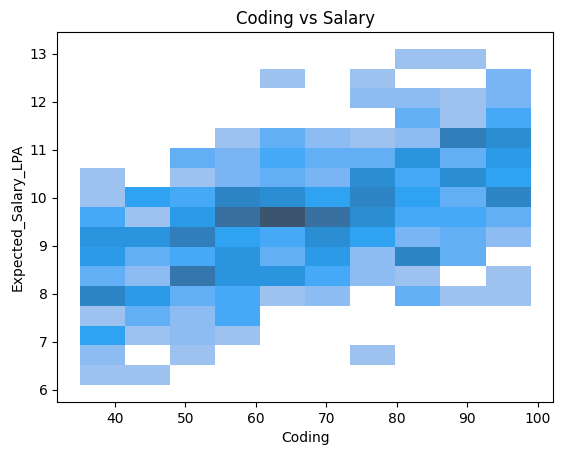

R2 Score = 0.8690726092786613
Logistic Accuracy = 0.878
KNN Accuracy = 0.776


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score, accuracy_score

# Read Dataset
df = pd.read_csv("placement.csv")

# NumPy Analysis
print("Average Salary:", np.mean(df["Expected_Salary_LPA"]))

# Seaborn Graph
sns.histplot(x="Coding", y="Expected_Salary_LPA", data=df)
plt.title("Coding vs Salary")
plt.show()

# Linear Regression
X = df[["Aptitude","Coding","Communication",
        "Attendance","Projects","Internship"]]
y = df["Expected_Salary_LPA"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print("R2 Score =", r2_score(y_test, pred))

# Logistic Regression
X2 = df[["Aptitude","Coding","Communication",
         "Attendance","Projects",
         "Internship","Expected_Salary_LPA"]]
y2 = df["Selected"]

log = LogisticRegression(max_iter=1000)
log.fit(X2, y2)

print("Logistic Accuracy =", accuracy_score(y2, log.predict(X2)))

# KNN
df["Domain_Code"] = pd.factorize(df["Recommended_Domain"])[0]

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, df["Domain_Code"])

print("KNN Accuracy =", accuracy_score(
    df["Domain_Code"], knn.predict(X)))